In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
from imutils.object_detection import non_max_suppression

# Encontrar el logotipo de la gaseosa dentro de la carpeta imagenes

coca_logo_2.png -> matches que coinciden: 4
[X] coca_logo_2.png - no suficiente matches


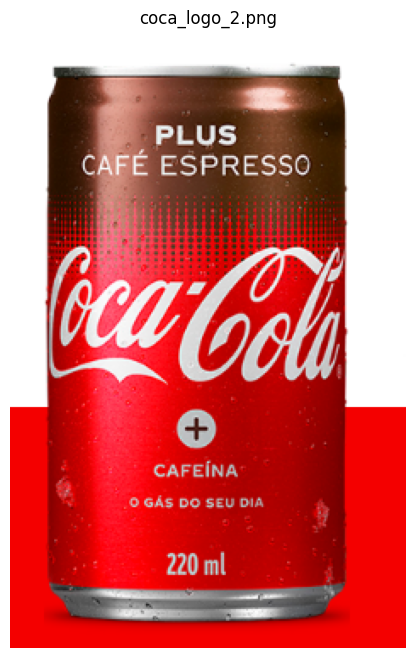

COCA-COLA-LOGO.jpg -> matches que coinciden: 5
[X] COCA-COLA-LOGO.jpg - no suficiente matches


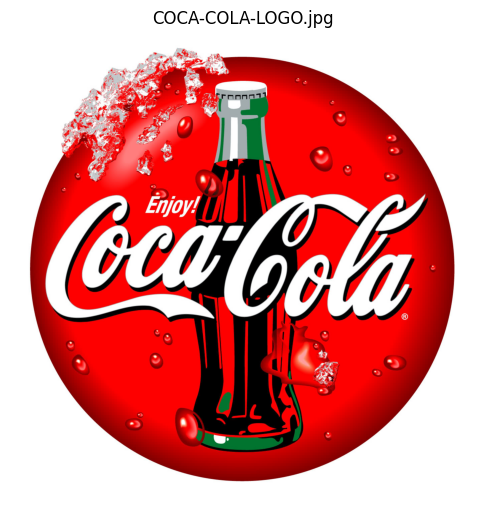

coca_retro_1.png -> matches que coinciden: 44
[OK] coca_retro_1.png - LOGO DETECTADO


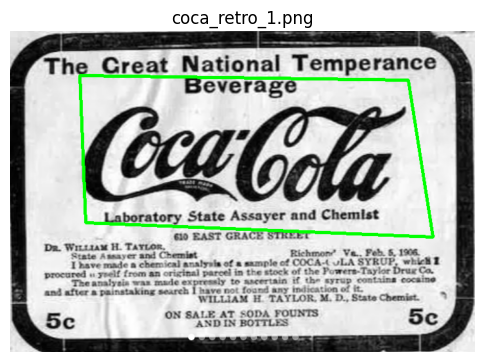

logo_1.png -> matches que coinciden: 3
[X] logo_1.png - no suficiente matches


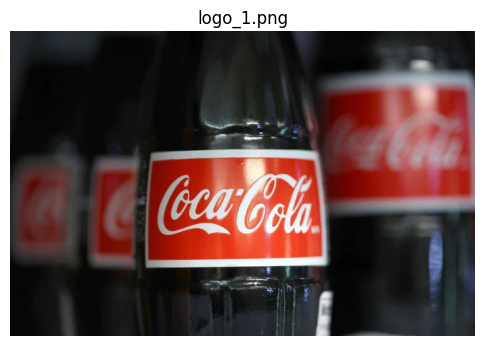

coca_retro_2.png -> matches que coinciden: 6
[X] coca_retro_2.png - no suficiente matches


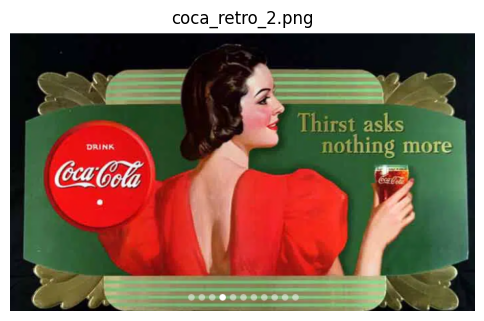

coca_multi.png -> matches que coinciden: 1
[X] coca_multi.png - no suficiente matches


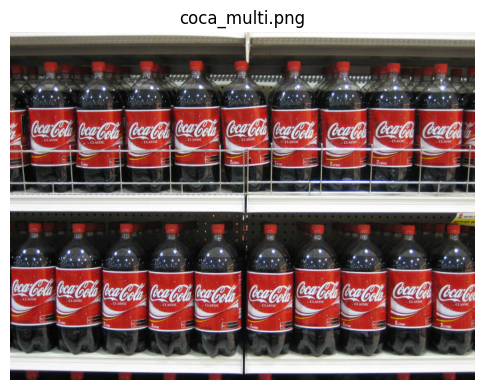

coca_logo_1.png -> matches que coinciden: 1
[X] coca_logo_1.png - no suficiente matches


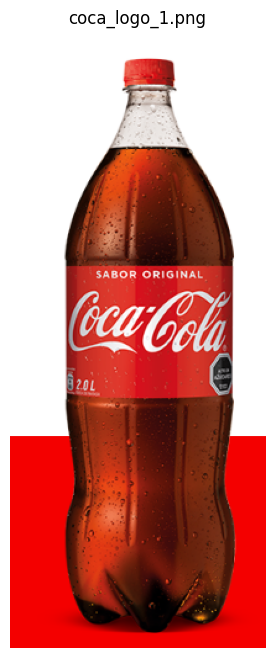

In [2]:
# =========================
# CONFIG
# =========================
images_path = "images"
template_path = "template/pattern.png"

MIN_MATCHES = 10
RATIO = 0.75

# =========================
# SE CARGA EL TEMPLATE
# =========================
template = cv.imread(template_path)

if template is None:
    raise ValueError("Error cargando template")
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

# ORB
orb = cv.ORB_create(nfeatures=3000)
kp1, des1 = orb.detectAndCompute(template_gray, None)

# matcher
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=False)

# =========================
# RECORRER LAS IMÁGENES
# =========================
for filename in os.listdir(images_path):

    img_path = os.path.join(images_path, filename)
    img = cv.imread(img_path)

    if img is None:
        continue

    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    kp2, des2 = orb.detectAndCompute(img_gray, None)

    if des2 is None:
        print(f"[X] {filename} - sin descriptores")
        continue

    # =========================
    # MATCHING
    # =========================
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < RATIO * n.distance:
            good.append(m)

    print(f"{filename} -> matches que coinciden: {len(good)}")

    # =========================
    # DETECCIÓN
    # =========================
    if len(good) >= MIN_MATCHES:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)

        if M is not None:

            h, w = template_gray.shape
            pts = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)
            dst = cv.perspectiveTransform(pts, M)
            cv.polylines(img_rgb, [np.int32(dst)], True, (0,255,0), 3)

            print(f"[OK] {filename} - LOGO DETECTADO")

        else:
            print(f"[X] {filename} - homografía inválida")

    else:
        print(f"[X] {filename} - no suficiente matches")

    # =========================
    # VISUALIZACIÓN
    # =========================
    plt.figure(figsize=(6,8))
    plt.imshow(img_rgb)
    plt.title(filename)
    plt.axis("off")
    plt.show()

# Análisis de la implementación de la parte 1

## Detección de logotipo mediante Extracción de caracteristicas

Para resolver la detección del logotipo en las imágenes provistas, se implementó un enfoque basado en extracción de características locales. Se observa que en las diferentes imágenes el logo aparece con variantes, como rotaciones, cambios de iluminación y diferencias de color, lo cual dificulta la aplicación de métodos basados en comparación directa.

Por este motivo, se propone un algoritmo basado en la detección de puntos característicos (keypoints) y la extracción de descriptores locales utilizando el método ORB. Este enfoque permite representar el logotipo mediante un conjunto de características invariantes.

El método demostró ser adecuado para el problema planteado, logrando detectar correctamente el logotipo en distintas condiciones, con una baja tasa de falsos positivos gracias a la validación geométrica.

Se utilizó el criterio de (ratio test) con un umbral de 0.75 para eliminar correspondencias ambiguas. Se estableció un mínimo de 10 correspondencias válidas para considerar la detección como válida, garantizando consistencia geométrica suficiente para la estimación de la homografía.

Por último RANSAC para estimar una homografía entre el template y la imagen, permitiendo filtrar correspondencias inconsistentes y reducir falsos positivos. Este paso asegura que las coincidencias respeten una estructura geométrica válida.

# Parte 2 - Algoritmo para multiples detecciones

MAX: 0.32164297
Detecciones: 3
MAX: 0.32164297


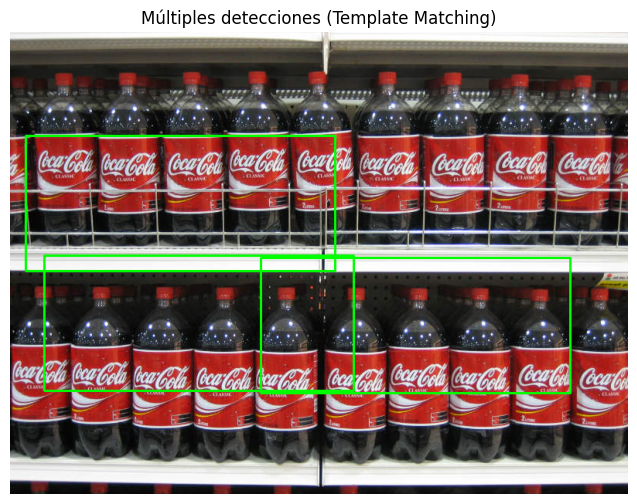

In [3]:
# =========================
# NMS (IoU)
# =========================
def non_max_suppression(boxes, overlapThresh=0.3):

    if len(boxes) == 0:
        return []

    boxes = boxes.astype(float)
    pick = []

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]

    area = (x2 - x1) * (y2 - y1)
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)

        suppress = [len(idxs)-1]

        for pos in range(len(idxs)-1):
            i = idxs[pos]

            xx1 = max(x1[last], x1[i])
            yy1 = max(y1[last], y1[i])
            xx2 = min(x2[last], x2[i])
            yy2 = min(y2[last], y2[i])

            w = max(0, xx2 - xx1)
            h = max(0, yy2 - yy1)

            overlap = (w * h) / area[i]

            if overlap > overlapThresh:
                suppress.append(pos)

        idxs = np.delete(idxs, suppress)

    return boxes[pick].astype(int)

# =========================
# CARGA de la imagen
# =========================
img = cv.imread("images/coca_multi.png")
template = cv.imread("template/pattern.png")

if img is None or template is None:
    raise ValueError("Error cargando imágenes")

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

h, w = template_gray.shape

# =========================
# TEMPLATE MATCHING
# =========================
res = cv.matchTemplate(img_gray, template_gray, cv.TM_CCOEFF_NORMED)

max_val = np.max(res)
print("MAX:", max_val)

threshold = 0.8 * max_val  #

(y_points, x_points) = np.where(res >= threshold)

boxes = []

for (x, y) in zip(x_points, y_points):
    boxes.append([x, y, x + w, y + h])

boxes = np.array(boxes)

# =========================
# NMS (IoU)
# =========================
boxes = non_max_suppression(boxes, overlapThresh=0.3)

# =========================
# RESULTADO
# =========================
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

for (x1, y1, x2, y2) in boxes:
    cv.rectangle(img_rgb, (x1, y1), (x2, y2), (0,255,0), 2)

print("Detecciones:", len(boxes))
print("MAX:", np.max(res))
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Múltiples detecciones (Template Matching)")
plt.axis("off")
plt.show()

# Template Matching para la detección de múltiple logos

El algoritmo propuesto basado en template matching permitió detectar múltiples instancias del logotipo dentro de una misma imagen mediante el análisis del mapa de correlación generado entre la imagen y el template.

Para este caso se observa que para la única imagen a analizar los logos no presentan mayor diversidad como en la primera parte, por lo que template matching para una imagen es un buen metodo.
Asimismo, la incorporación de Non-Max Suppression (NMS) basado en Intersection over Union (IoU) permitió eliminar detecciones redundantes sobre una misma instancia del objeto, conservando únicamente las regiones con mayor coincidencia. Esto mejora significativamente la precisión del algoritmo en escenarios con múltiples coincidencias cercanas.

El algoritmo logra un buen desempeño para la detección múltiple, constituyendo una solución simple y eficiente. No obstante, para escenarios más complejos, resulta necesario recurrir a métodos basados en características locales como en la primera parte.

## Adecuar el algoritmo para detectar en todas las imagenes dadas

[SKIP] coca_logo_2.png - imagen más chica que el template
COCA-COLA-LOGO.jpg -> detecciones: 17 (max=0.28)


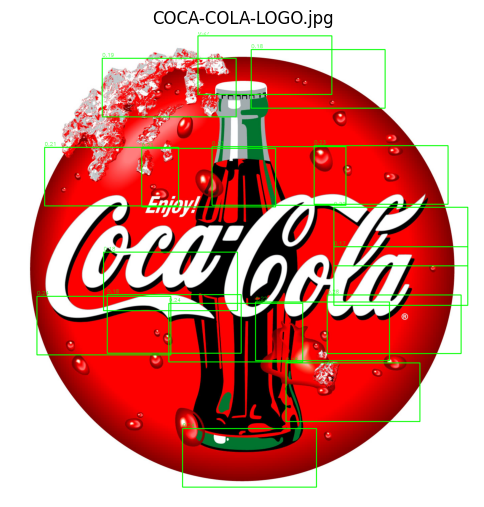

coca_retro_1.png -> detecciones: 2 (max=0.27)


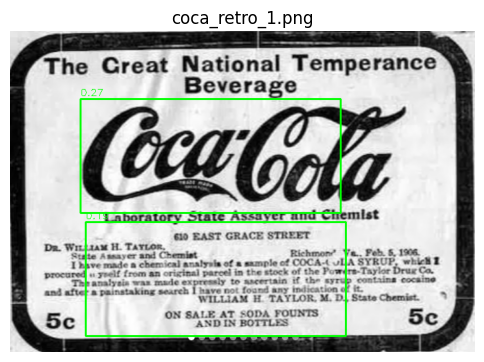

logo_1.png -> detecciones: 4 (max=0.15)


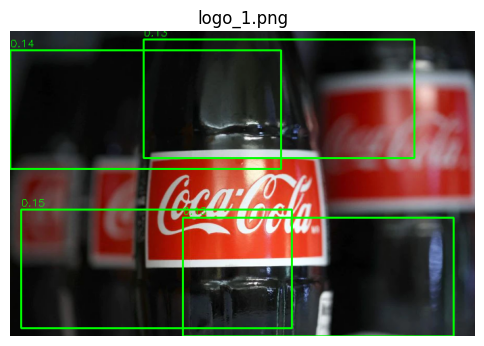

coca_retro_2.png -> detecciones: 1 (max=0.28)


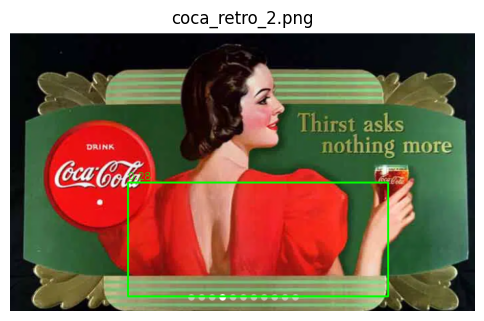

coca_multi.png -> detecciones: 8 (max=0.32)


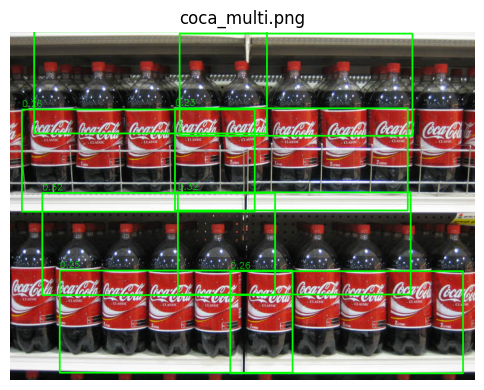

[SKIP] coca_logo_1.png - imagen más chica que el template


In [5]:
# =========================
# NMS (IoU)
# =========================
def non_max_suppression(boxes, scores, overlapThresh=0.3):

    if len(boxes) == 0:
        return []

    boxes = boxes.astype(float)
    scores = scores.astype(float)

    pick = []

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]

    area = (x2 - x1) * (y2 - y1)
    idxs = np.argsort(scores)  # ordenar por score

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)

        suppress = [len(idxs)-1]

        for pos in range(len(idxs)-1):
            i = idxs[pos]

            xx1 = max(x1[last], x1[i])
            yy1 = max(y1[last], y1[i])
            xx2 = min(x2[last], x2[i])
            yy2 = min(y2[last], y2[i])

            w = max(0, xx2 - xx1)
            h = max(0, yy2 - yy1)

            inter = w * h
            iou = inter / (area[i] + area[last] - inter + 1e-6)

            if iou > overlapThresh:
                suppress.append(pos)

        idxs = np.delete(idxs, suppress)

    return pick

# =========================
# CONFIG
# =========================
images_path = "images"
template_path = "template/pattern.png"

# =========================
# TEMPLATE
# =========================
template = cv.imread(template_path)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

h, w = template_gray.shape

# =========================
# LOOP IMÁGENES
# =========================
for filename in os.listdir(images_path):

    img_path = os.path.join(images_path, filename)
    img = cv.imread(img_path)

    if img is None:
        continue

    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # =========================
    # TEMPLATE MATCHING
    # =========================
    if img_gray.shape[0] < template_gray.shape[0] or img_gray.shape[1] < template_gray.shape[1]:
      print(f"[SKIP] {filename} - imagen más chica que el template")
      continue
    res = cv.matchTemplate(img_gray, template_gray, cv.TM_CCOEFF_NORMED)

    max_val = np.max(res)

    # threshold adaptativo
    threshold = 0.6 * max_val

    (ys, xs) = np.where(res >= threshold)

    boxes = []
    scores = []

    for (x, y) in zip(xs, ys):
        score = res[y, x]

        boxes.append([x, y, x + w, y + h])
        scores.append(score)

    boxes = np.array(boxes)
    scores = np.array(scores)

    # =========================
    # NMS (IoU)
    # =========================
    keep = non_max_suppression(boxes, scores, overlapThresh=0.3)

    # =========================
    #  RESULTADOS
    # =========================
    for i in keep:
        x1, y1, x2, y2 = boxes[i]
        score = scores[i]

        cv.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0,255,0), 2)

        cv.putText(
            img_rgb,
            f"{score:.2f}",
            (int(x1), int(y1)-5),
            cv.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,0),
            1
        )

    print(f"{filename} -> detecciones: {len(keep)} (max={max_val:.2f})")

    # =========================
    # VISUALIZACIÓN
    # =========================
    plt.figure(figsize=(6,8))
    plt.imshow(img_rgb)
    plt.title(filename)
    plt.axis("off")
    plt.show()

# Conclusiones

El algoritmo implementado logra detectar algunas instancias del objeto, pero con precisión limitada.